## NB5 — Gene Program Negotiation (GPN) on cNMF Usage Programs

**Pipeline:** NB1 (GSEA cell-type scoring) → NB2 (`per_gep_labels.tsv`, GEP tree) → NB4 (ROGUE purity audit) → NB5 (this notebook).

**Source:** Sung & Cheong, *Gene Program Negotiation Defines Cellular Identity in Single-Cell Transcriptomes*, bioRxiv 2026 (doi: 10.64898/2026.07.05.736629).

**Reframing for this pipeline:** GPN was built around independently-scored Hallmark gene programs (stemness, EMT, hypoxia, ...). This pipeline already has a richer, purpose-built multi-program decomposition: the **cNMF usage matrix** — every cell's continuous, non-negative activity across all GEPs at a given K. That *is* GPN's "program activity matrix." So instead of re-deriving program scores, this notebook runs GPN's graph math directly on cNMF's own usage output, at every K NB1/NB2/NB4 already scored, and validates the resulting regulatory states against artifacts those notebooks already produced — rather than the paper's own pseudotime-based validation, which scores "transition-like cells" from the same conflict/diversity/GPCI values it then validates against. NB4's ROGUE purity is a fully independent instability proxy, so it stands in for that step here.

**What's adapted from the paper, and why:**
- **Programs = GEPs**, not Hallmark sets. `*.usages.k_{K}.dt_0_01.consensus.txt` (cells × GEPs) is the activity matrix for every K.
- **Neighborhood graph = kNN on Harmony space** (`adata.obsm['X_harmony']`), not raw PCA. This dataset pools 63 patients (`orig.ident`); NB4 explicitly scores ROGUE *within-sample* to keep batch structure from being read as biology. The same risk applies to GPN's local-correlation neighborhoods, so we use the batch-corrected embedding and explicitly audit same-sample vs. cross-sample neighbor composition (§3) instead of assuming it away.
- **"Positive program activities" is a no-op here.** cNMF usage is non-negative by construction (it's an NMF), so raw usage is used directly for activation weights / total activity / dominance / diversity. Z-scoring (which *can* go negative) is used only for the local correlation graph, exactly as the paper's Methods describe for that one step.
- **Diagonal (self-interaction) terms are excluded** from every graph sum (coherence, conflict). A program's correlation with itself is always 1 and carries no information about cross-program interaction — leaving it in would mechanically inflate coherence and deflate conflict as a pure artifact of matrix size.
- **K is swept, not fixed.** GPN metrics are computed for every K where NB1's GSEA output, NB2's `per_gep_labels.tsv`, NB1's `gep_program_class.tsv`, and NB4's ROGUE tables all exist (K = 4–20 — see §4), so every GPN state can be jointly validated against identity, identity-confidence, and purity at the same resolution.
- **Classification thresholds are the paper's starting values** (20th / 62% / 80th / 70th / 60th percentile cutoffs), shown against this dataset's own distributions in §7 before being applied in §8 — re-tune there if the diagnostic plots look off for this dataset, the same way NB1 §7.2–7.3 tunes its own GSEA thresholds.

In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.neighbors import NearestNeighbors
from scipy.stats import kruskal, chi2_contingency, fisher_exact, spearmanr
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### 1. Configuration

In [2]:
# Paths — same source data as NB4
ADATA_PATH = "hnc_data/hnc_myeloid_2021.h5ad"
METADATA_PATH = "hnc_data/hnc_myeloid_globalcluster4.csv"
BARCODE_COL = None
METADATA_SEP = ","
BASELINE_LABEL_COL = "global.cluster4"

# Same cNMF outputs as NB1 / NB2 / NB4
CNMF_DIR = "hnc_consensus_outputs_k3-35/combined_hnc_k_consensus_outputs"
CNMF_PREFIX = "combined_hnc_k"
DENSITY_THRESHOLD = "0_01"
K_MIN, K_MAX = 4, 20   # bounded by per_gep_labels.tsv / ROGUE coverage — see §4

# NB2 output — one identity label per (K, GEP)
LABELS_PATH = "hnc_combined5000hvg_clanp_results/k3-35_corr-tree_kl-divergence/per_gep_labels.tsv"

# NB1 output — one identity-confidence class per (K, GEP)
PROGRAM_CLASS_PATH = "hnc_combined5000hvg_clanp_results/k3-35_gsea_celltype_results/gep_program_class.tsv"

# NB4 outputs — ROGUE purity per (sample, K, GEP)
ROGUE_SPLIT_MERGE_PATH = "hnc_combined5000hvg_clanp_results/rogue_purity_results_per_gep/rogue_split_merge_signal.csv"
ROGUE_CONTAMINATION_PATH = "hnc_combined5000hvg_clanp_results/rogue_purity_results_per_gep/rogue_contamination.csv"

# Neighborhood graph
EMBEDDING_KEY = "X_harmony"   # batch-corrected; X_pca is also available but not batch-corrected
EMBEDDING_DIMS = 30           # matches the paper's "15 nearest neighbors within 30 PCs"
N_NEIGHBORS = 15
MIN_NEIGHBORS_FOR_GRAPH = 3   # skip GPCI/conflict for cells with fewer usable neighbors

# GPN state-classification thresholds — paper's starting values (Methods).
# Inspect §7's diagnostic plots against this dataset before trusting these.
LOW_ACTIVITY_PERCENTILE       = 20    # bottom 20% of total activity -> Low activity
DOMINANCE_FRACTION            = 0.62  # dominant GEP's share of total activity -> Dominance
COMPETITION_PERCENTILE        = 80    # top 20% local conflict -> Competition
CONSENSUS_GPCI_PERCENTILE     = 70    # GPCI above this pctile ...
CONSENSUS_CONFLICT_PERCENTILE = 60    # ... AND conflict below this pctile -> Consensus
STATE_ORDER = ["Low activity", "Dominance", "Competition", "Consensus", "Negotiation"]

REPRESENTATIVE_K = 10   # single K used for the UMAP figures in §12

OUT_DIR = "hnc_combined5000hvg_clanp_results/gpn_results_per_gep"
os.makedirs(OUT_DIR, exist_ok=True)
print("Configuration loaded.")

Configuration loaded.


### 2. Load cells, samples, embedding, baseline labels

No raw counts needed — GPN operates on the cNMF usage matrix and the existing Harmony embedding, not on gene expression directly.

In [3]:
adata = sc.read_h5ad(ADATA_PATH)
if EMBEDDING_KEY not in adata.obsm:
    raise KeyError(f"{EMBEDDING_KEY} not found in adata.obsm — available: {list(adata.obsm.keys())}")

embedding = adata.obsm[EMBEDDING_KEY][:, :EMBEDDING_DIMS]
cell_names = adata.obs_names.astype(str).to_numpy()
cell_to_pos = {c: i for i, c in enumerate(cell_names)}

samples_full = adata.obs['orig.ident'].astype(str)
samples_full.index = cell_names

meta = pd.read_csv(METADATA_PATH, sep=METADATA_SEP,
                    index_col=0 if BARCODE_COL is None else None)
if BARCODE_COL is not None:
    meta = meta.set_index(BARCODE_COL)
meta.index = meta.index.astype(str)
original_labels = meta[BASELINE_LABEL_COL].astype(str)

print(f"{len(cell_names)} cells, {samples_full.nunique()} samples, "
      f"{EMBEDDING_KEY} truncated to {embedding.shape[1]} dims")

26444 cells, 63 samples, X_harmony truncated to 30 dims


### 3. Shared cell neighborhood graph

Built once on the Harmony embedding and reused for every K — the same "compute once, reuse across K" pattern NB4 uses for `expr_full` in the R session.

Then a diagnostic: what fraction of each cell's neighbors come from the *same* sample. If this space were perfectly batch-corrected, same-sample fraction should track each sample's share of its cell's local cell-type neighborhood, not sit near 100%. High same-sample mixing would mean GPN's "local co-regulation" is partly reading batch structure rather than biology.

Neighbor graph: 15 neighbors per cell on X_harmony[:, :30]
Same-sample neighbor fraction: mean=0.165, median=0.133


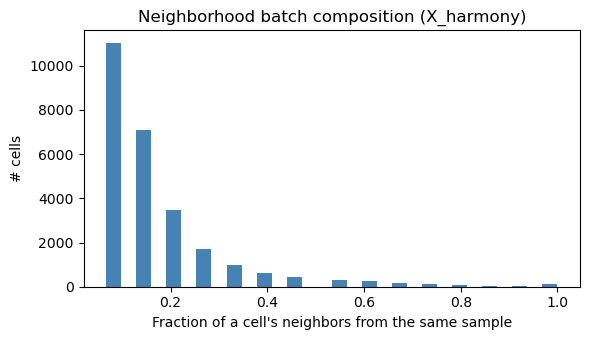

In [4]:
nn = NearestNeighbors(n_neighbors=N_NEIGHBORS).fit(embedding)
_, neighbor_idx = nn.kneighbors(embedding)   # (n_cells, N_NEIGHBORS) positions into cell_names/embedding

same_sample_frac = np.array([
    (samples_full.iloc[neighbor_idx[i]].to_numpy() == samples_full.iloc[i]).mean()
    for i in range(len(cell_names))
])

print(f"Neighbor graph: {N_NEIGHBORS} neighbors per cell on {EMBEDDING_KEY}[:, :{EMBEDDING_DIMS}]")
print(f"Same-sample neighbor fraction: mean={same_sample_frac.mean():.3f}, "
      f"median={np.median(same_sample_frac):.3f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(same_sample_frac, bins=30, color='steelblue')
ax.set(xlabel="Fraction of a cell's neighbors from the same sample",
       ylabel='# cells',
       title=f'Neighborhood batch composition ({EMBEDDING_KEY})')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'neighborhood_batch_composition.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4. Discover usable K values

Every downstream validation in this notebook joins against NB1's and NB2's and NB4's outputs, so we restrict the whole sweep to K values where **all four** sources exist — rather than silently dropping rows later. `gep_program_class.tsv` and the cNMF usage files cover K=3–35; `per_gep_labels.tsv` and the ROGUE tables only cover K=4–20, which sets the effective range.

In [ ]:
def usage_path(k):
    return os.path.join(CNMF_DIR, f"{CNMF_PREFIX}.usages.k_{k}.dt_{DENSITY_THRESHOLD}.consensus.txt")

usage_pattern = os.path.join(CNMF_DIR, f"{CNMF_PREFIX}.usages.k_*.dt_{DENSITY_THRESHOLD}.consensus.txt")
k_usage = {int(m.group(1)) for f in glob.glob(usage_pattern)
           if (m := re.search(r'k_(\d+)', os.path.basename(f)))}

labels_df = pd.read_csv(LABELS_PATH, sep='\t')
labels_df['k'] = labels_df['k'].astype(int)
labels_df['gep'] = labels_df['gep'].astype(str)
k_labels = set(labels_df['k'].unique())

program_class_df = pd.read_csv(PROGRAM_CLASS_PATH, sep='\t')
program_class_df['k'] = program_class_df['k'].astype(int)
program_class_df['gep'] = program_class_df['gep'].astype(str)
k_program_class = set(program_class_df['k'].unique())

rogue_df = pd.read_csv(ROGUE_SPLIT_MERGE_PATH)
rogue_df['K'] = rogue_df['K'].astype(int)
rogue_df['gep'] = rogue_df['gep'].astype(str)
k_rogue = set(rogue_df['K'].unique())

requested = set(range(K_MIN, K_MAX + 1))
k_values = sorted(k_usage & k_labels & k_program_class & k_rogue & requested)
dropped = sorted(((k_usage | k_labels | k_program_class | k_rogue) & requested) - set(k_values))

print(f"Usable K values (usage ∩ per_gep_labels ∩ gep_program_class ∩ ROGUE, within [{K_MIN},{K_MAX}]): {k_values}")
if dropped:
    print(f"Dropped (present in some but not all sources): {dropped}")

### 5. GPN core math — per-cell program interaction graph

For each cell *i* at a given K, with raw usage vector `u_i` (non-negative, length K) and its `N_NEIGHBORS` nearest cells in Harmony space:

- **Coherence graph** `C_i` — Pearson correlation between GEPs computed *within the neighborhood*, on z-scored usage (z-scoring is across all cells, per GEP; the correlation itself is local).
- **Activation weights** `W_i = outer(u_i, u_i)` — magnitude gating from the cell's own raw usage (already non-negative, so no ReLU step is needed here unlike the paper's score-based activities).
- **Interaction graph** `G_i = C_i ⊙ W_i`.
- **Coherence** `= sum(G_i, off-diag) / sum(|W_i|, off-diag)`.
- **Conflict** `= sum(|G_i|, off-diag, G_i<0) / sum(|W_i|, off-diag)`.
- **Total activity** `A_i = sum(u_i)`; **dominance share** `= max(u_i)/A_i`; **diversity** `D_i = exp(Shannon entropy of u_i/A_i)`.
- **GPCI** `= coherence × log(1+A_i) × D_i/K`.

Cached to `OUT_DIR/gpn_metrics_K{k}.csv` per K, the same cache-if-exists pattern NB4 uses for its ROGUE tables.

In [ ]:
def load_usage(k):
    u = pd.read_csv(usage_path(k), sep='\t', index_col=0)
    u.index = u.index.astype(str)
    u.columns = u.columns.astype(str)
    return u

def compute_gpn_for_k(k, out_path):
    """Per-cell GPCI, conflict, diversity, dominance, activity, and dominant GEP for one K."""
    if os.path.exists(out_path):
        return pd.read_csv(out_path, index_col=0)

    usage = load_usage(k)
    common = [c for c in usage.index if c in cell_to_pos]
    usage = usage.loc[common]

    U = usage.to_numpy(dtype=np.float64)               # raw, non-negative: cells x programs
    n_cells, n_prog = U.shape
    positions = np.array([cell_to_pos[c] for c in usage.index])
    pos_to_row = {p: r for r, p in enumerate(positions)}

    # z-scored usage — used only for the local correlation graph
    mu, sd = U.mean(axis=0), U.std(axis=0)
    sd_safe = np.where(sd > 0, sd, 1.0)
    Z = (U - mu) / sd_safe

    total_activity = U.sum(axis=1)                      # A_i
    with np.errstate(divide='ignore', invalid='ignore'):
        shares = np.where(total_activity[:, None] > 0, U / total_activity[:, None], 0.0)
    dominance_share = shares.max(axis=1)
    with np.errstate(divide='ignore', invalid='ignore'):
        plogp = np.where(shares > 0, shares * np.log(shares), 0.0)
    diversity = np.exp(-plogp.sum(axis=1))               # D_i, effective # active programs

    off_diag = ~np.eye(n_prog, dtype=bool)
    coherence = np.full(n_cells, np.nan)
    conflict = np.full(n_cells, np.nan)

    for r in tqdm(range(n_cells), desc=f"GPN graphs K={k}"):
        full_pos = positions[r]
        nb_rows = [pos_to_row[p] for p in neighbor_idx[full_pos] if p in pos_to_row]
        if len(nb_rows) < MIN_NEIGHBORS_FOR_GRAPH:
            continue
        with np.errstate(invalid='ignore'):
            C = np.corrcoef(Z[nb_rows], rowvar=False)
        C = np.nan_to_num(C, nan=0.0)
        W = np.outer(U[r], U[r])
        G = C * W
        w_abs_sum = np.abs(W[off_diag]).sum()
        if w_abs_sum == 0:
            coherence[r] = 0.0
            conflict[r] = 0.0
            continue
        coherence[r] = G[off_diag].sum() / w_abs_sum
        neg_mask = G[off_diag] < 0
        conflict[r] = np.abs(G[off_diag][neg_mask]).sum() / w_abs_sum

    gpci = coherence * np.log1p(total_activity) * (diversity / n_prog)
    dominant_gep = usage.columns.to_numpy()[U.argmax(axis=1)]

    df = pd.DataFrame({
        'cell': usage.index, 'K': k, 'gep': dominant_gep,
        'activity': total_activity, 'dominance_share': dominance_share,
        'coherence': coherence, 'conflict': conflict,
        'diversity': diversity, 'GPCI': gpci,
    }).set_index('cell')
    df.to_csv(out_path)
    return df

print("GPN core functions defined.")

### 6. Compute GPN metrics for every K

In [ ]:
gpn_metrics_parts = []
for k in k_values:
    out_path = os.path.join(OUT_DIR, f"gpn_metrics_K{k}.csv")
    gpn_metrics_parts.append(compute_gpn_for_k(k, out_path))

gpn_metrics = pd.concat(gpn_metrics_parts, ignore_index=False).reset_index()
gpn_metrics['sample'] = gpn_metrics['cell'].map(samples_full)

print(f"{len(gpn_metrics)} (cell, K) rows across K = {k_values}")
gpn_metrics[['activity', 'dominance_share', 'coherence', 'conflict', 'diversity', 'GPCI']].describe().round(3)

### 7. Threshold diagnostic

Before locking in state assignments, look at where this dataset's activity / dominance / conflict / GPCI distributions actually sit relative to the paper's default cutoffs — the same practice NB1 §7.2–7.3 uses for its own GSEA thresholds. If a line falls somewhere that doesn't look like a meaningful cutpoint in this dataset's distribution, adjust the corresponding `*_PERCENTILE` / `DOMINANCE_FRACTION` constant in §1 and re-run from this cell — §6's cached per-K files don't need to be rebuilt, since none of this touches the graph computation.

In [ ]:
pooled = gpn_metrics
print("Pooled quantiles across all K (for reference only — classification below uses per-K percentiles):")
print(pooled[['activity', 'dominance_share', 'conflict', 'GPCI']].quantile([.2, .5, .6, .7, .8, .9]).round(3).to_string())

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

axes[0].hist(np.log1p(pooled['activity']), bins=60, color='steelblue')
axes[0].axvline(np.log1p(np.percentile(pooled['activity'], LOW_ACTIVITY_PERCENTILE)),
                color='crimson', ls='--', label=f'{LOW_ACTIVITY_PERCENTILE}th pctile (pooled)')
axes[0].set(title='log1p(total activity)', xlabel='log1p(activity)'); axes[0].legend(fontsize=8)

axes[1].hist(pooled['dominance_share'], bins=60, color='seagreen')
axes[1].axvline(DOMINANCE_FRACTION, color='crimson', ls='--', label=f'{DOMINANCE_FRACTION} fixed cutoff')
axes[1].set(title='dominant-GEP share of total activity', xlabel='dominance_share'); axes[1].legend(fontsize=8)

axes[2].hist(pooled['conflict'].dropna(), bins=60, color='indianred')
axes[2].axvline(np.percentile(pooled['conflict'].dropna(), COMPETITION_PERCENTILE),
                color='crimson', ls='--', label=f'{COMPETITION_PERCENTILE}th pctile (pooled)')
axes[2].set(title='local conflict', xlabel='conflict'); axes[2].legend(fontsize=8)

axes[3].hist(pooled['GPCI'].dropna(), bins=60, color='goldenrod')
axes[3].axvline(np.percentile(pooled['GPCI'].dropna(), CONSENSUS_GPCI_PERCENTILE),
                color='crimson', ls='--', label=f'{CONSENSUS_GPCI_PERCENTILE}th pctile (pooled)')
axes[3].set(title='GPCI', xlabel='GPCI'); axes[3].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'threshold_diagnostic.png'), dpi=150, bbox_inches='tight')
plt.show()

### 8. Classify regulatory decision states

Thresholds are computed **per K** (each K has a different number of GEPs, so pooling percentiles across K would mix incomparable scales), then applied as a strict priority order — exactly the if/elif chain in the paper's Methods, where an earlier rule always wins over a later one:

`Low activity` (bottom `LOW_ACTIVITY_PERCENTILE`% activity) > `Dominance` (dominant share > `DOMINANCE_FRACTION`) > `Competition` (top `COMPETITION_PERCENTILE`% conflict) > `Consensus` (GPCI ≥ `CONSENSUS_GPCI_PERCENTILE`th pctile AND conflict ≤ `CONSENSUS_CONFLICT_PERCENTILE`th pctile) > else `Negotiation`.

In [ ]:
def classify_states(df):
    out = df.copy()
    out['state'] = None
    for k, idx in out.groupby('K').groups.items():
        sub = out.loc[idx]
        low_cut = np.percentile(sub['activity'], LOW_ACTIVITY_PERCENTILE)
        comp_cut = np.percentile(sub['conflict'].dropna(), COMPETITION_PERCENTILE)
        gpci_cut = np.percentile(sub['GPCI'].dropna(), CONSENSUS_GPCI_PERCENTILE)
        cons_conflict_cut = np.percentile(sub['conflict'].dropna(), CONSENSUS_CONFLICT_PERCENTILE)

        # Applied in reverse priority so the highest-priority rule is written last and wins.
        state = pd.Series('Negotiation', index=sub.index)
        state[(sub['GPCI'] >= gpci_cut) & (sub['conflict'] <= cons_conflict_cut)] = 'Consensus'
        state[sub['conflict'] >= comp_cut] = 'Competition'
        state[sub['dominance_share'] > DOMINANCE_FRACTION] = 'Dominance'
        state[sub['activity'] <= low_cut] = 'Low activity'
        out.loc[idx, 'state'] = state
    return out

gpn_states = classify_states(gpn_metrics)
print(gpn_states.groupby('K')['state'].value_counts(normalize=True).unstack()[STATE_ORDER].round(3).to_string())

**Coverage check** (mirrors NB1 §7.6): every cell scored gets exactly one valid state, and no K silently lost cells during the `cell_to_pos` intersection in §5.

In [ ]:
VALID_STATES = set(STATE_ORDER)
problems = []

bad_states = set(gpn_states['state'].dropna().unique()) - VALID_STATES
if bad_states:
    problems.append(f"invalid state value(s): {bad_states}")
n_missing = gpn_states['state'].isna().sum()
if n_missing:
    problems.append(f"{n_missing} rows with no state assigned")

for k in k_values:
    n_usage_cells = len(load_usage(k).index)
    n_scored = (gpn_states['K'] == k).sum()
    if n_scored < 0.99 * n_usage_cells:
        problems.append(f"K={k}: only {n_scored}/{n_usage_cells} usage-matrix cells were scored "
                         f"(likely missing from adata/{EMBEDDING_KEY})")

if problems:
    print("Coverage check found issues:\n  - " + "\n  - ".join(problems))
else:
    print(f"✓ Coverage check passed: {len(gpn_states)} (cell,K) rows, "
          f"all states valid, ≥99% of usage-matrix cells scored at every K.")

### 9. Validation A — GPN states vs. NB2 dominant-program identity

Each cell's dominant GEP (its own argmax usage, computed in §5) is looked up against NB2's `per_gep_labels.tsv` to get that GEP's cell-type identity — the same "dominant program" axis as the paper's Fig. 3A/6A. If a single identity label spans multiple GPN states, and GPCI varies significantly within it, that reproduces the paper's central claim: dominant program identity alone does not determine regulatory organization.

In [ ]:
gpn_states = gpn_states.merge(
    labels_df.rename(columns={'k': 'K'})[['K', 'gep', 'label']],
    on=['K', 'gep'], how='left'
)
print(f"{gpn_states['label'].isna().mean():.1%} of (cell,K) rows have no NB2 label (unexpected gep id) — should be ~0%.")

state_by_label = pd.crosstab(gpn_states['label'], gpn_states['state'], normalize='index')[STATE_ORDER]
state_by_label.to_csv(os.path.join(OUT_DIR, 'state_composition_by_label.csv'))

fig, ax = plt.subplots(figsize=(max(8, len(state_by_label) * 0.6), 5))
state_by_label.plot(kind='bar', stacked=True, ax=ax,
                     color=sns.color_palette('Set2', n_colors=len(STATE_ORDER)))
ax.set(ylabel='Fraction of cells', xlabel='Dominant GEP identity (NB2 label)',
       title='GPN state composition by dominant-program identity')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='GPN state', fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'state_composition_by_label.png'), dpi=150, bbox_inches='tight')
plt.show()

groups = [g['GPCI'].dropna().to_numpy() for _, g in gpn_states.groupby('label') if g['GPCI'].notna().sum() >= 10]
stat, p = kruskal(*groups)
print(f"\nKruskal–Wallis, GPCI across dominant-program labels: H={stat:.1f}, p={p:.3g}")
print("A label spanning multiple GPN states (bars above not solid) plus a significant GPCI difference "
      "reproduce the paper's Fig. 3C/D and 6C.")

### 10. Validation B — GPN states vs. NB1 identity confidence

NB1 already flags which (K, GEP) pairs have *no* significant cell-type enrichment at all (`non_identity_unresolved`) versus a confident call (`identity_supported` / `identity_ambiguous`). The paper has no equivalent independent confidence label — this is a check unique to this pipeline: an identity-agnostic GEP should look regulatory-unstable (Low activity / Negotiation), not falsely Consensus.

In [ ]:
gpn_states = gpn_states.merge(
    program_class_df.rename(columns={'k': 'K'})[['K', 'gep', 'program_class']],
    on=['K', 'gep'], how='left'
)

ct = pd.crosstab(gpn_states['program_class'], gpn_states['state'])[STATE_ORDER]
print(ct.to_string())
chi2, p, dof, _ = chi2_contingency(ct)
print(f"\nChi-square (program_class x GPN state): chi2={chi2:.1f}, dof={dof}, p={p:.3g}")

unresolved = gpn_states['program_class'] == 'non_identity_unresolved'
uncertain_state = gpn_states['state'].isin(['Low activity', 'Negotiation'])
table_2x2 = pd.crosstab(unresolved, uncertain_state)
odds_ratio, p_fisher = fisher_exact(table_2x2)
print(f"\n2x2: non_identity_unresolved x {{Low activity, Negotiation}} — "
      f"odds ratio={odds_ratio:.2f}, Fisher p={p_fisher:.3g}")

ct.to_csv(os.path.join(OUT_DIR, 'state_vs_program_class.csv'))

### 11. Validation C — GPN states vs. NB4 ROGUE purity (independent instability signal)

This is the check the paper couldn't do: it validated "Competition ~ instability" against a transition score built from the *same* conflict/diversity/GPCI values being validated. Here, ROGUE purity per (sample, K, GEP) comes from a completely separate computation (full-transcriptome entropy in NB4) that never sees GPN's outputs. If GEPs with a higher Competition fraction / higher mean conflict / lower mean GPCI also score lower on ROGUE, that's a genuinely external validation.

In [ ]:
agg = (gpn_states.groupby(['sample', 'K', 'gep'])
       .agg(n_cells=('state', 'size'),
            competition_frac=('state', lambda s: (s == 'Competition').mean()),
            consensus_frac=('state', lambda s: (s == 'Consensus').mean()),
            mean_GPCI=('GPCI', 'mean'),
            mean_conflict=('conflict', 'mean'))
       .reset_index())

rogue = rogue_df[['sample', 'K', 'gep', 'ROGUE', 'baseline_ROGUE', 'delta_ROGUE', 'recommendation']]
contam = pd.read_csv(ROGUE_CONTAMINATION_PATH)
contam['K'] = contam['K'].astype(int)
contam['gep'] = contam['gep'].astype(str)
contam = contam[['sample', 'K', 'gep', 'contamination_delta']]

merged = (agg.merge(rogue, on=['sample', 'K', 'gep'], how='inner')
             .merge(contam, on=['sample', 'K', 'gep'], how='left'))
merged.to_csv(os.path.join(OUT_DIR, 'gpn_vs_rogue.csv'), index=False)
print(f"{len(merged)} (sample, K, GEP) groups joined against ROGUE (of {len(agg)} GPN groups, "
      f"{len(rogue)} ROGUE rows)")

for x, y in [('competition_frac', 'ROGUE'), ('mean_conflict', 'ROGUE'), ('mean_GPCI', 'ROGUE')]:
    sub = merged[[x, y]].dropna()
    rho, p = spearmanr(sub[x], sub[y])
    print(f"  Spearman({x}, {y}) = {rho:.3f}  (p={p:.3g}, n={len(sub)})")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (x, y) in zip(axes, [('competition_frac', 'ROGUE'), ('mean_conflict', 'ROGUE'), ('mean_GPCI', 'ROGUE')]):
    ax.scatter(merged[x], merged[y], s=8, alpha=0.4, color='steelblue')
    ax.set(xlabel=x, ylabel=y)
plt.suptitle('GPN regulatory metrics vs. NB4 ROGUE purity, per (sample, K, GEP)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'gpn_vs_rogue.png'), dpi=150, bbox_inches='tight')
plt.show()

### 12. Visualization — UMAP colored by GPCI / conflict / state

Uses `adata.obsm['X_umap']`, already computed — no need to rebuild it. `REPRESENTATIVE_K` (§1) picks which K's states are shown; change it and re-run this cell to inspect a different resolution.

In [ ]:
umap_df = pd.DataFrame(adata.obsm['X_umap'], columns=['UMAP1', 'UMAP2'], index=cell_names)

viz = gpn_states[gpn_states['K'] == REPRESENTATIVE_K].set_index('cell').join(umap_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sc0 = axes[0].scatter(viz['UMAP1'], viz['UMAP2'], c=viz['GPCI'], cmap='viridis', s=3)
axes[0].set(title=f'GPCI (K={REPRESENTATIVE_K})', xlabel='UMAP1', ylabel='UMAP2')
plt.colorbar(sc0, ax=axes[0], shrink=0.8)

sc1 = axes[1].scatter(viz['UMAP1'], viz['UMAP2'], c=viz['conflict'], cmap='inferno', s=3)
axes[1].set(title=f'Local conflict (K={REPRESENTATIVE_K})', xlabel='UMAP1', ylabel='UMAP2')
plt.colorbar(sc1, ax=axes[1], shrink=0.8)

state_colors = dict(zip(STATE_ORDER, sns.color_palette('Set2', n_colors=len(STATE_ORDER))))
for state, color in state_colors.items():
    sub = viz[viz['state'] == state]
    axes[2].scatter(sub['UMAP1'], sub['UMAP2'], s=3, color=color, label=state)
axes[2].set(title=f'GPN state (K={REPRESENTATIVE_K})', xlabel='UMAP1', ylabel='UMAP2')
axes[2].legend(markerscale=3, fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'umap_gpn_K{REPRESENTATIVE_K}.png'), dpi=150, bbox_inches='tight')
plt.show()

### 13. Save master outputs + summary

In [ ]:
master_path = os.path.join(OUT_DIR, 'gpn_states.tsv')
gpn_states.to_csv(master_path, sep='\t', index=False)

print("GPN analysis complete.\n")
print(f"K values analyzed: {k_values}")
print(f"Total (cell, K) rows: {len(gpn_states)}")
print("\nOverall state distribution:")
print(gpn_states['state'].value_counts(normalize=True).round(3).to_string())
print(f"\nOutputs written to {OUT_DIR}/:")
for f in sorted(os.listdir(OUT_DIR)):
    print(f"  {f}")